## Experiment

We investigate whether introducing stochasticity into latent dynamics improves robustness to distribution shift caused by changes in observation density. Our study focuses on a comparison between a deterministic Neural Controlled Differential Equation (Neural CDE) and a Neural Langevin-type Stochastic Differential Equation (Neural LSDE) with diagonal latent noise.

The Neural LSDE follows the formulation introduced in *Stable Neural Stochastic Differential Equations in Analyzing Irregular Time Series Data* by YongKyung Oh, Dong-Young Lim, and Sungil Kim, where the authors argue that stochastic latent dynamics can stabilize learning and improve generalization under distribution shift. In particular, the original work claims that LSDEs are more robust than deterministic counterparts when the training and test data distributions differ.

To directly test this claim in a controlled setting, we design an experiment that isolates **missingness-induced distribution shift**. Both models are trained on the same regression task: predicting a scalar parameter that controls the shape of a spiral trajectory from irregularly sampled time series observations. Importantly, **training is performed only on the densest observation regime**, while evaluation is conducted on datasets with progressively fewer observations. The underlying data-generating process is held fixed; only the observation process is altered.

The central hypothesis is that latent stochasticity regularizes the learned vector field, reduces sensitivity to interpolation artifacts, and encourages smoother latent dynamics. As a result, the LSDE is expected to degrade more slowly than the deterministic CDE as observation density decreases. We therefore emphasize not only absolute predictive accuracy, but also **the rate at which error increases with missingness**, measured using mean squared error (MSE) and mean absolute error (MAE), and analyzed via both linear and exponential error-vs-missingness trends.

Our results support the original claim: the Neural LSDE exhibits consistently slower degradation under increasing missingness, indicating improved robustness to this form of distribution shift.

## Models

We compare two latent differential equation models with matched architectural capacity: a deterministic Neural Controlled Differential Equation (Neural CDE) and a stochastic Neural Langevin-type Stochastic Differential Equation (Neural LSDE). Both models operate in latent space and are driven by the same interpolated control path constructed from the observed time series.

### Neural CDE (Deterministic Baseline)

The Neural CDE serves as a deterministic baseline. Given an interpolated control path $X(t)$, the latent state evolves according to

$$
\mathrm{d}z(t) = f\big(t, z(t), X(t)\big)\,\mathrm{d}t.
$$

The latent vector field $f$ is parameterized by a multilayer perceptron that conditions jointly on the current latent state and the control value at time $t$. The initial latent state $z(t_0)$ is obtained by applying a linear map to the first observed control value. A linear decoder maps the final latent state to the target scalar.

This model produces a single latent trajectory for each input sequence. As a result, any change in observation density alters the interpolated control path and can induce brittle changes in the latent dynamics, making the model sensitive to missingness patterns.

### Neural LSDE (Stochastic Latent Dynamics)

The Neural LSDE augments the deterministic CDE with additive stochasticity in latent space:

$$
\mathrm{d}z(t) = f\big(t, z(t), X(t)\big)\,\mathrm{d}t + g(t)\,\mathrm{d}W(t),
$$

where $g(t)$ parameterizes a diagonal diffusion term and $W(t)$ is a Wiener process. The drift function $f$ is architecturally identical to that of the Neural CDE, ensuring a fair comparison. The diffusion term depends only on time, implemented via a sinusoidal time embedding followed by an MLP, and outputs a strictly positive diagonal noise scale.

This design choice mirrors the formulation in *Stable Neural Stochastic Differential Equations in Analyzing Irregular Time Series Data* and isolates the effect of latent stochasticity without introducing additional dependence on the latent state. The stochastic term acts as an implicit regularizer, encouraging smoother vector fields and reducing sensitivity to exact interpolation details.

### Shared Architectural and Training Choices

To ensure comparability, both models:
- Use the same input channels $[t_{\text{norm}}, x_{\text{norm}}, y_{\text{norm}}]$ and the same cubic interpolation scheme.
- Share the same latent dimensionality, MLP depth, and width.
- Use identical initialization, normalization, decoder structure, and training objectives.
- Are trained with the same optimizer, learning rate, and training budget.

The only substantive difference between the two models is the presence or absence of latent stochasticity. This allows any observed differences in performance degradation under missingness to be attributed directly to the stochastic dynamics introduced by the LSDE.

In [15]:
# Neural LSDE in Equinox + Diffrax
# dz(t) = f(t, z(t), X(t)) dt + g(t) dW(t)
#
# Fixes applied:
# - Use CubicInterpolation (consistent with cubic coeffs).
# - Diffusion is strictly positive with a floor via softplus (unbounded above).
# - dt0 set to a fixed resolution (n_steps=512) for consistent discretization across missingness.
# - BrownianTree tol tied to dt0 (keeps Brownian approximation consistent if dt0 changes).
# - Minor hygiene: explicitly del unused args in diffusion.
# - IMPORTANT FIX: when evolving_out=False, decode the final latent state (sol.ys[-1] or sol.ys),
#   avoiding shape issues with SaveAt(t1=True).

import equinox as eqx
import diffrax as dfx
import lineax as lx
import jax
import jax.numpy as jnp


def lipswish(x):
    return 0.909 * jax.nn.silu(x)


class MLP(eqx.Module):
    net: eqx.nn.MLP

    def __init__(
        self,
        in_size,
        out_size,
        width_size,
        depth,
        *,
        key,
        activation="lipswish",
        final_activation=None,
    ):
        if activation == "lipswish":
            act = lipswish
        elif activation == "tanh":
            act = jax.nn.tanh
        else:
            act = jax.nn.relu

        if final_activation is None:
            final_activation = lambda x: x

        self.net = eqx.nn.MLP(
            in_size=in_size,
            out_size=out_size,
            width_size=width_size,
            depth=depth,
            activation=act,
            final_activation=final_activation,
            key=key,
        )

    def __call__(self, x):
        return self.net(x)


class LSDEFunc(eqx.Module):
    # Drift pieces
    linear_X: eqx.nn.Linear
    emb: eqx.nn.Linear
    f_net: MLP
    linear_out: eqx.nn.Linear

    # Diffusion pieces (time-only)
    noise_in: eqx.nn.Linear
    g_net: MLP

    hidden_dim: int
    sigma_floor: float

    def __init__(
        self,
        input_dim,
        hidden_dim,
        width_size,
        depth,
        *,
        key,
        activation="lipswish",
        sigma_floor=1e-3,
    ):
        k1, k2, k3, k4, k5, k6 = jax.random.split(key, 6)
        self.hidden_dim = hidden_dim
        self.sigma_floor = float(sigma_floor)

        self.linear_X = eqx.nn.Linear(input_dim, hidden_dim, key=k1)
        self.emb = eqx.nn.Linear(2 * hidden_dim, hidden_dim, key=k2)
        self.f_net = MLP(hidden_dim, hidden_dim, width_size, depth, key=k3, activation=activation)
        self.linear_out = eqx.nn.Linear(hidden_dim, hidden_dim, key=k4)

        # sin/cos time embed -> hidden_dim
        self.noise_in = eqx.nn.Linear(2, hidden_dim, key=k5)
        self.g_net = MLP(hidden_dim, hidden_dim, width_size, depth, key=k6, activation=activation)

    def drift(self, t, z, *, control):
        Xt = control.evaluate(t)              # (input_dim,)
        Xt = self.linear_X(Xt)                # (hidden_dim,)
        h = self.emb(jnp.concatenate([z, Xt], axis=-1))
        h = self.f_net(h)
        return self.linear_out(h)             # (hidden_dim,)

    def diffusion(self, t, z, *, control):
        # Time-only diffusion (additive), diagonal noise. Enforce positivity + floor.
        del z, control

        # Robust to t being scalar or shape (1,) under vmap/jit.
        t = jnp.asarray(t).reshape(())
        tt = jnp.array([jnp.sin(t), jnp.cos(t)])  # (2,)

        h = self.noise_in(tt)                 # (hidden_dim,)
        raw = self.g_net(h)                   # (hidden_dim,)

        diag = jax.nn.softplus(raw) + self.sigma_floor  # strictly > sigma_floor, unbounded above

        return lx.DiagonalLinearOperator(diag)


class NeuralLSDE(eqx.Module):
    func: LSDEFunc
    initial: eqx.nn.Linear
    decoder: eqx.nn.Linear
    hidden_dim: int
    input_dim: int
    n_steps: int

    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        *,
        key,
        width_size=64,
        depth=1,
        activation="lipswish",
        sigma_floor=1e-3,
        n_steps=512,
    ):
        kf, ki, kd = jax.random.split(key, 3)
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.n_steps = int(n_steps)

        self.func = LSDEFunc(
            input_dim,
            hidden_dim,
            width_size,
            depth,
            key=kf,
            activation=activation,
            sigma_floor=sigma_floor,
        )
        self.initial = eqx.nn.Linear(input_dim, hidden_dim, key=ki)
        self.decoder = eqx.nn.Linear(hidden_dim, output_dim, key=kd)

    def __call__(self, ts, coeffs, *, key, evolving_out=True, dt0=None):
        # Control path: cubic interpolation over (ts, coeffs).
        control = dfx.CubicInterpolation(ts, coeffs)

        t0, t1 = ts[0], ts[-1]

        # Fixed solver step for consistent discretization across missingness.
        if dt0 is None:
            dt0 = (t1 - t0) / self.n_steps

        # Tie Brownian approximation tolerance to dt0 for consistency.
        tol = jnp.minimum(jnp.asarray(1e-3), jnp.asarray(dt0))

        brownian = dfx.VirtualBrownianTree(
            t0=t0, t1=t1, tol=tol, shape=(self.hidden_dim,), key=key
        )

        drift_term = dfx.ODETerm(lambda t, z, args: self.func.drift(t, z, control=control))
        diff_term = dfx.ControlTerm(
            lambda t, z, args: self.func.diffusion(t, z, control=control),
            brownian,
        )
        terms = dfx.MultiTerm(drift_term, diff_term)

        # Initial latent state from the first observation/control value.
        z0 = self.initial(control.evaluate(t0))  # (hidden_dim,)

        saveat = dfx.SaveAt(ts=ts) if evolving_out else dfx.SaveAt(t1=True)

        sol = dfx.diffeqsolve(
            terms=terms,
            solver=dfx.EulerHeun(),
            t0=t0,
            t1=t1,
            dt0=dt0,
            y0=z0,
            saveat=saveat,
        )

        if evolving_out:
            zt = sol.ys                           # (T, hidden_dim)
            yt = jax.vmap(self.decoder)(zt)       # (T, output_dim)
            return yt
        else:
            # With SaveAt(t1=True), sol.ys is typically (hidden_dim,).
            # With other SaveAt configs, sol.ys could be (T, hidden_dim).
            # Handle both safely by decoding the final latent state.
            z_final = sol.ys[-1] if sol.ys.ndim == 2 else sol.ys
            return self.decoder(z_final)           # (output_dim,)

In [16]:
# Neural CDE baseline in Equinox + Diffrax
# dz(t) = f(t, z(t), X(t)) dt
#
# Matched to NeuralLSDE:
# - Same drift network (linear_X, emb, f_net, linear_out)
# - Same initial mapping z0 = initial(X(t0))
# - Same decoder
# - Same control path interface: CubicInterpolation(ts, coeffs)
# - Same dt0 scheme via n_steps
# - Same SaveAt behavior (evolving_out True/False)
# - IMPORTANT FIX: when evolving_out=False, decode the final latent state safely

import equinox as eqx
import diffrax as dfx
import jax
import jax.numpy as jnp


def lipswish(x):
    return 0.909 * jax.nn.silu(x)


class MLP(eqx.Module):
    net: eqx.nn.MLP

    def __init__(
        self,
        in_size,
        out_size,
        width_size,
        depth,
        *,
        key,
        activation="lipswish",
        final_activation=None,
    ):
        if activation == "lipswish":
            act = lipswish
        elif activation == "tanh":
            act = jax.nn.tanh
        else:
            act = jax.nn.relu

        if final_activation is None:
            final_activation = lambda x: x

        self.net = eqx.nn.MLP(
            in_size=in_size,
            out_size=out_size,
            width_size=width_size,
            depth=depth,
            activation=act,
            final_activation=final_activation,
            key=key,
        )

    def __call__(self, x):
        return self.net(x)


class CDEFunc(eqx.Module):
    # Drift pieces (identical to LSDE drift)
    linear_X: eqx.nn.Linear
    emb: eqx.nn.Linear
    f_net: MLP
    linear_out: eqx.nn.Linear
    hidden_dim: int

    def __init__(self, input_dim, hidden_dim, width_size, depth, *, key, activation="lipswish"):
        k1, k2, k3, k4 = jax.random.split(key, 4)
        self.hidden_dim = hidden_dim

        self.linear_X = eqx.nn.Linear(input_dim, hidden_dim, key=k1)
        self.emb = eqx.nn.Linear(2 * hidden_dim, hidden_dim, key=k2)
        self.f_net = MLP(hidden_dim, hidden_dim, width_size, depth, key=k3, activation=activation)
        self.linear_out = eqx.nn.Linear(hidden_dim, hidden_dim, key=k4)

    def drift(self, t, z, *, control):
        Xt = control.evaluate(t)              # (input_dim,)
        Xt = self.linear_X(Xt)                # (hidden_dim,)
        h = self.emb(jnp.concatenate([z, Xt], axis=-1))
        h = self.f_net(h)
        return self.linear_out(h)             # (hidden_dim,)


class NeuralCDE(eqx.Module):
    func: CDEFunc
    initial: eqx.nn.Linear
    decoder: eqx.nn.Linear
    hidden_dim: int
    input_dim: int
    n_steps: int

    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        *,
        key,
        width_size=64,
        depth=1,
        activation="lipswish",
        n_steps=512,
    ):
        kf, ki, kd = jax.random.split(key, 3)
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.n_steps = int(n_steps)

        self.func = CDEFunc(input_dim, hidden_dim, width_size, depth, key=kf, activation=activation)
        self.initial = eqx.nn.Linear(input_dim, hidden_dim, key=ki)
        self.decoder = eqx.nn.Linear(hidden_dim, output_dim, key=kd)

    def __call__(self, ts, coeffs, *, evolving_out=True, dt0=None):
        control = dfx.CubicInterpolation(ts, coeffs)

        t0, t1 = ts[0], ts[-1]

        # Match LSDE discretization choice.
        if dt0 is None:
            dt0 = (t1 - t0) / self.n_steps

        term = dfx.ODETerm(lambda t, z, args: self.func.drift(t, z, control=control))

        z0 = self.initial(control.evaluate(t0))  # (hidden_dim,)

        saveat = dfx.SaveAt(ts=ts) if evolving_out else dfx.SaveAt(t1=True)

        sol = dfx.diffeqsolve(
            terms=term,
            solver=dfx.Heun(),  # IMPORTANT: ODE solver (EulerHeun is for SDEs and expects MultiTerm)
            t0=t0,
            t1=t1,
            dt0=dt0,
            y0=z0,
            saveat=saveat,
        )

        if evolving_out:
            zt = sol.ys
            yt = jax.vmap(self.decoder)(zt)
            return yt
        else:
            z_final = sol.ys[-1] if sol.ys.ndim == 2 else sol.ys
            return self.decoder(z_final)

## Dataset

We evaluate both models on a synthetic spiral regression dataset designed to produce irregularly sampled time series with a controlled notion of missingness. Each sample consists of a sequence of observations $(t_i, x_i, y_i)$ generated from a planar spiral whose shape is governed by a single scalar parameter $\alpha$. The learning task is to recover $\alpha$ from the observed trajectory.

To study robustness under missingness-induced distribution shift, the dataset is provided at four different observation densities: **spirals\_100**, **spirals\_75**, **spirals\_50**, and **spirals\_25**, where the suffix indicates the relative number of observed time points. All datasets share the same underlying generative process; only the observation density and pattern differ.

In all experiments, models are trained exclusively on the densest dataset (spirals\_100) and evaluated on all four densities. This setup isolates the effect of changing observation patterns while keeping the task and data distribution fixed, allowing us to directly assess robustness to missingness.

In [17]:
from typing import Tuple
import numpy as np

def load_spiral_dataset(name: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Load one of the spiral datasets (e.g., 'spirals_100.npz', 'spirals_75.npz', etc.)
    from the 'data/' subfolder.
    
    Parameters
    ----------
    name : str
        Dataset identifier (e.g., '100', '75', '50', '25')
    
    Returns
    -------
    data_train : np.ndarray
        Training set, shape (1000, n, 3)  [t, x, y]
    alpha_train : np.ndarray
        Training α values, shape (1000, 1)
    data_validation : np.ndarray
        Validation set, shape (1000, n, 3)
    alpha_validation : np.ndarray
        Validation α values, shape (1000, 1)
    data_test : np.ndarray
        Test set, shape (1000, n, 3)
    """
    path = f"data/spirals_{name}.npz"
    data = np.load(path)
    
    data_train = data["data_train"]
    alpha_train = data["alpha_train"]
    data_validation = data["data_validation"]
    alpha_validation = data["alpha_validation"]
    data_test = data["data_test"]
    
    print(f"✅ Loaded spirals_{name}")
    print(f"   Train data: {data_train.shape}, α_train: {alpha_train.shape}")
    print(f"   Validation data: {data_validation.shape}, α_val: {alpha_validation.shape}")
    print(f"   Test data: {data_test.shape}")
    
    return data_train, alpha_train, data_validation, alpha_validation, data_test

# Load all datasets (unchanged)
datasets = {}
for density in ['100', '75', '50', '25']:
    data_train, alpha_train, data_val, alpha_val, data_test = load_spiral_dataset(density)
    datasets[density] = {
        'data_train': data_train,
        'alpha_train': alpha_train,
        'data_val': data_val,
        'alpha_val': alpha_val,
        'data_test': data_test
    }
    print()

✅ Loaded spirals_100
   Train data: (1000, 100, 3), α_train: (1000, 1)
   Validation data: (1000, 100, 3), α_val: (1000, 1)
   Test data: (1000, 100, 3)

✅ Loaded spirals_75
   Train data: (1000, 75, 3), α_train: (1000, 1)
   Validation data: (1000, 75, 3), α_val: (1000, 1)
   Test data: (1000, 75, 3)

✅ Loaded spirals_50
   Train data: (1000, 50, 3), α_train: (1000, 1)
   Validation data: (1000, 50, 3), α_val: (1000, 1)
   Test data: (1000, 50, 3)

✅ Loaded spirals_25
   Train data: (1000, 25, 3), α_train: (1000, 1)
   Validation data: (1000, 25, 3), α_val: (1000, 1)
   Test data: (1000, 25, 3)



## Normalization

To ensure stable training and fair comparison across observation densities, we apply consistent normalization based solely on the training data. Time is normalized to the interval $[0,1]$ on a per-sequence basis, while the spatial coordinates $(x, y)$ are standardized using global mean and standard deviation computed from the training split of the densest dataset (spirals\_100).

The target parameter $\alpha$ is similarly standardized during training and predictions are denormalized at evaluation time. Importantly, normalization statistics are **never recomputed for sparser datasets**, preventing any leakage of test-time information and ensuring that all models are evaluated under the same normalization regime.

In [18]:
import equinox as eqx
import jax.numpy as jnp
import numpy as np
import diffrax as dfx


class NormalizedRegressor(eqx.Module):
    """
    Wrapper that:
    - normalizes time to [0,1] per sequence
    - standardizes x/y inputs using training stats
    - standardizes alpha targets using training stats (for training-time loss if you want)
    - denormalizes alpha predictions back to original scale

    Model-agnostic:
    - If core_model is stochastic (LSDE), pass key (PRNGKey).
    - If core_model is deterministic (CDE), you can pass key=None.
    """
    core_model: eqx.Module
    mean_xy: jnp.ndarray
    std_xy: jnp.ndarray
    mean_alpha: jnp.ndarray
    std_alpha: jnp.ndarray

    def __init__(self, core_model, data_train, alpha_train):
        self.core_model = core_model

        # Compute normalization stats from training data only.
        xy_train = data_train[..., 1:]  # (B, T, 2)
        self.mean_xy = jnp.array(np.mean(xy_train, axis=(0, 1)), dtype=jnp.float32)
        self.std_xy = jnp.array(np.std(xy_train, axis=(0, 1)) + 1e-8, dtype=jnp.float32)

        # alpha_train typically shape (B, 1) - keep scalar stats.
        self.mean_alpha = jnp.array(np.mean(alpha_train), dtype=jnp.float32)
        self.std_alpha = jnp.array(np.std(alpha_train) + 1e-8, dtype=jnp.float32)

        print("✅ Normalization wrapper initialized")
        print(f"   x/y mean={self.mean_xy}, std={self.std_xy}")
        print(f"   alpha mean={float(self.mean_alpha):.4f}, std={float(self.std_alpha):.4f}")

    # ---------- normalization helpers ----------

    def normalize_time(self, t):
        """
        Normalize time to [0,1] per sequence.
        t: (T,) or (B,T)
        """
        if t.ndim == 1:
            t_min = jnp.min(t)
            t_max = jnp.max(t)
        elif t.ndim == 2:
            t_min = jnp.min(t, axis=1, keepdims=True)
            t_max = jnp.max(t, axis=1, keepdims=True)
        else:
            raise ValueError(f"t must have shape (T,) or (B,T); got {t.shape}")
        return (t - t_min) / (t_max - t_min + 1e-8)

    def normalize_xy(self, xy):
        """Standardize x,y coordinates."""
        return (xy - self.mean_xy) / self.std_xy

    def normalize_alpha(self, alpha):
        """Standardize alpha target."""
        return (alpha - self.mean_alpha) / self.std_alpha

    def denormalize_alpha(self, alpha_norm):
        """Convert normalized alpha back to original scale."""
        return alpha_norm * self.std_alpha + self.mean_alpha

    # ---------- forward ----------

    def __call__(self, data, *, key=None):
        """
        Parameters
        ----------
        data : jnp.ndarray
            shape (T,3) = [t, x, y]
        key : PRNGKey or None
            For stochastic models (LSDE). Deterministic models can pass None.

        Returns
        -------
        alpha_hat : scalar (original alpha scale)
        """
        # Split data
        t = data[:, 0]        # (T,)
        xy = data[:, 1:]      # (T,2)

        # Normalize using per-sequence time range and global xy stats
        t_norm = self.normalize_time(t)       # (T,)
        xy_norm = self.normalize_xy(xy)       # (T,2)

        # Control path input: [t_norm, x_norm, y_norm]
        control_input = jnp.concatenate([t_norm[:, None], xy_norm], axis=-1)  # (T,3)

        # Coeffs for CubicInterpolation
        coeffs = dfx.backward_hermite_coefficients(t_norm, control_input)

        # Forward through core model
        # - LSDE expects key
        # - CDE ignores key (we don't pass it)
        if key is None:
            alpha_norm = self.core_model(t_norm, coeffs, evolving_out=False)
        else:
            alpha_norm = self.core_model(t_norm, coeffs, key=key, evolving_out=False)

        # Denormalize prediction back to original alpha scale
        return self.denormalize_alpha(alpha_norm)

## Training Objective and Procedure

Both models are trained to predict the spiral parameter $\alpha$ using a mean squared error (MSE) loss between predicted and true values. Training is performed on mini-batches drawn from the densest dataset (spirals\_100) only, using the Adam optimizer with a fixed learning rate.

For the Neural LSDE, stochasticity is handled by sampling one independent latent trajectory per training example at each optimization step, yielding an unbiased stochastic estimate of the loss. The Neural CDE is trained deterministically under the same batching and optimization regime. Aside from the presence of latent noise in the LSDE, all training settings - including optimizer, batch size, and number of epochs - are kept identical to ensure a fair comparison.

In [19]:
import equinox as eqx
import jax
import jax.numpy as jnp
import optax


def mse(pred, true):
    pred = jnp.squeeze(pred)
    true = jnp.squeeze(true)
    return jnp.mean((pred - true) ** 2)


@eqx.filter_value_and_grad
def loss_fn(model, data_batch, y_batch, *, key=None):
    """
    Model-agnostic loss:
    - If key is provided: assume stochastic model (LSDE) and use one key per sample.
    - If key is None: assume deterministic model (CDE) and do not pass keys.
    """
    batch_size = data_batch.shape[0]

    if key is None:
        # Deterministic path
        y_pred = jax.vmap(lambda data: model(data))(data_batch)
    else:
        # Stochastic path: one independent key per sample
        keys = jax.random.split(key, batch_size)
        y_pred = jax.vmap(lambda data, k: model(data, key=k))(data_batch, keys)

    return mse(y_pred, y_batch)


@eqx.filter_jit
def train_step(model, opt_state, data_batch, y_batch, optimizer, *, key=None):
    loss, grads = loss_fn(model, data_batch, y_batch, key=key)
    updates, opt_state = optimizer.update(
        grads, opt_state, eqx.filter(model, eqx.is_inexact_array)
    )
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state

In [20]:
# Train NeuralLSDE vs NeuralCDE side-by-side on spirals_100, using identical normalization stats
# Assumes you already defined/imported:
# - NeuralLSDE (core)
# - NeuralCDE (core)
# - NormalizedRegressor (wrapper; accepts key=None for deterministic models)
# - loss_fn / train_step / mse (model-agnostic versions that accept key=None)

import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax


# ------------------------
# Train on densest dataset only (per experiment)
# ------------------------
train_density = "100"
data_train_np = datasets[train_density]["data_train"]        # (B, T, 3) [t, x, y]
alpha_train_np = datasets[train_density]["alpha_train"]      # (B, 1) or (B,)
data_val_np = datasets[train_density]["data_val"]
alpha_val_np = datasets[train_density]["alpha_val"]

# Convert to JAX arrays
data_train = jnp.array(data_train_np, dtype=jnp.float32)
y_train = jnp.array(alpha_train_np, dtype=jnp.float32).reshape(-1)  # (B,)
data_val = jnp.array(data_val_np, dtype=jnp.float32)
y_val = jnp.array(alpha_val_np, dtype=jnp.float32).reshape(-1)

B_train, T, D = data_train.shape
assert D == 3, f"Expected [t,x,y] channels, got D={D}"


# ------------------------
# Build both core models
# ------------------------
input_dim = 3
hidden_dim = 32
output_dim = 1
depth = 1
width_size = 64

key = jr.PRNGKey(0)
k_lsde, k_cde, train_key = jr.split(key, 3)

core_lsde = NeuralLSDE(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    key=k_lsde,
    width_size=width_size,
    depth=depth,
    activation="lipswish",
)

core_cde = NeuralCDE(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    key=k_cde,
    width_size=width_size,
    depth=depth,
    activation="lipswish",
)

# Same normalization stats for both (computed ONLY from spirals_100 train split)
model_lsde = NormalizedRegressor(core_lsde, data_train_np, alpha_train_np)
model_cde = NormalizedRegressor(core_cde, data_train_np, alpha_train_np)


# ------------------------
# Optimizers (separate states, same hyperparams)
# ------------------------
lr = 1e-3
optimizer = optax.adam(lr)

opt_state_lsde = optimizer.init(eqx.filter(model_lsde, eqx.is_inexact_array))
opt_state_cde = optimizer.init(eqx.filter(model_cde, eqx.is_inexact_array))


# ------------------------
# Simple batcher (yields indices so both models see identical batches)
# ------------------------
def make_epoch_batches_idx(n, batch_size, *, key):
    perm = jr.permutation(key, n)
    for start in range(0, n - batch_size + 1, batch_size):
        yield perm[start : start + batch_size]


# ------------------------
# Training loop
# ------------------------
num_epochs = 20
batch_size = 64

for epoch in range(1, num_epochs + 1):
    train_key, perm_key = jr.split(train_key, 2)

    # Train
    train_losses_lsde = []
    train_losses_cde = []

    for idx in make_epoch_batches_idx(B_train, batch_size, key=perm_key):
        xb = data_train[idx]
        yb = y_train[idx]

        # LSDE update (stochastic - needs per-step key)
        train_key, step_key = jr.split(train_key, 2)
        loss_lsde, model_lsde, opt_state_lsde = train_step(
            model_lsde, opt_state_lsde, xb, yb, optimizer, key=step_key
        )
        train_losses_lsde.append(loss_lsde)

        # CDE update (deterministic - no key)
        loss_cde, model_cde, opt_state_cde = train_step(
            model_cde, opt_state_cde, xb, yb, optimizer, key=None
        )
        train_losses_cde.append(loss_cde)

    train_loss_lsde = float(jnp.mean(jnp.stack(train_losses_lsde)))
    train_loss_cde = float(jnp.mean(jnp.stack(train_losses_cde)))

    # Val (subset for speed)
    val_key, train_key = jr.split(train_key, 2)
    val_losses_lsde = []
    val_losses_cde = []

    for i, idx in enumerate(make_epoch_batches_idx(data_val.shape[0], batch_size, key=val_key)):
        xb = data_val[idx]
        yb = y_val[idx]

        # LSDE val loss
        val_key, step_key = jr.split(val_key, 2)
        val_loss_lsde, _ = loss_fn(model_lsde, xb, yb, key=step_key)
        val_losses_lsde.append(val_loss_lsde)

        # CDE val loss
        val_loss_cde, _ = loss_fn(model_cde, xb, yb, key=None)
        val_losses_cde.append(val_loss_cde)

        if i >= 4:
            break

    val_loss_lsde = float(jnp.mean(jnp.stack(val_losses_lsde)))
    val_loss_cde = float(jnp.mean(jnp.stack(val_losses_cde)))

    print(
        f"Epoch {epoch:03d} | "
        f"LSDE train MSE {train_loss_lsde:.6f} val MSE {val_loss_lsde:.6f} | "
        f"CDE  train MSE {train_loss_cde:.6f} val MSE {val_loss_cde:.6f}"
    )

✅ Normalization wrapper initialized
   x/y mean=[ 0.00221817 -0.04279724], std=[13.228789 13.00915 ]
   alpha mean=0.0571, std=2.4921
✅ Normalization wrapper initialized
   x/y mean=[ 0.00221817 -0.04279724], std=[13.228789 13.00915 ]
   alpha mean=0.0571, std=2.4921
Epoch 001 | LSDE train MSE 7.204050 val MSE 9.533900 | CDE  train MSE 6.050945 val MSE 9.073621
Epoch 002 | LSDE train MSE 6.720814 val MSE 5.305661 | CDE  train MSE 6.043210 val MSE 5.218821
Epoch 003 | LSDE train MSE 4.277820 val MSE 4.674930 | CDE  train MSE 4.780721 val MSE 5.742443
Epoch 004 | LSDE train MSE 1.311409 val MSE 0.262686 | CDE  train MSE 2.501687 val MSE 1.320521
Epoch 005 | LSDE train MSE 0.270129 val MSE 0.092413 | CDE  train MSE 0.343298 val MSE 0.538906
Epoch 006 | LSDE train MSE 0.111447 val MSE 0.120918 | CDE  train MSE 0.125082 val MSE 0.163761
Epoch 007 | LSDE train MSE 0.086550 val MSE 0.096464 | CDE  train MSE 0.095105 val MSE 0.055697
Epoch 008 | LSDE train MSE 0.073901 val MSE 0.051554 | CDE  

## Evaluation Protocol and Visualization

Model performance is evaluated on validation sets spanning all four observation densities, using models trained exclusively on the densest dataset. For each density, we report both mean squared error (MSE) and mean absolute error (MAE) to capture complementary aspects of predictive accuracy.

For the Neural LSDE, evaluation accounts for latent stochasticity by averaging predictions over multiple independent stochastic forward passes per sample. This Monte Carlo averaging reduces variance and provides a stable estimate of expected model performance. The Neural CDE is evaluated deterministically.

We visualize performance in several complementary ways. Scatter plots of predicted versus true $\alpha$ values illustrate calibration and systematic bias across densities, while error histograms highlight changes in error distribution as missingness increases. In addition, we plot MAE and MSE as explicit functions of missingness and fit both linear and exponential trends to these curves. These plots allow direct comparison of how prediction error evolves as observation density decreases, providing a clear basis for contrasting the robustness of the two models under missingness-induced distribution shift.


📊 Validation performance on spirals_100 (same trained models, LSDE averaged K=20)
   LSDE: MSE 0.043828 | MAE 0.107863 | Std 0.198065
   CDE : MSE 0.067172 | MAE 0.119006 | Std 0.247856

📊 Validation performance on spirals_75 (same trained models, LSDE averaged K=20)
   LSDE: MSE 0.053498 | MAE 0.121831 | Std 0.222057
   CDE : MSE 0.079302 | MAE 0.133277 | Std 0.272247

📊 Validation performance on spirals_50 (same trained models, LSDE averaged K=20)
   LSDE: MSE 0.132800 | MAE 0.176901 | Std 0.354589
   CDE : MSE 0.170466 | MAE 0.189886 | Std 0.402539

📊 Validation performance on spirals_25 (same trained models, LSDE averaged K=20)
   LSDE: MSE 0.365141 | MAE 0.285597 | Std 0.598910
   CDE : MSE 0.509685 | MAE 0.342212 | Std 0.708218


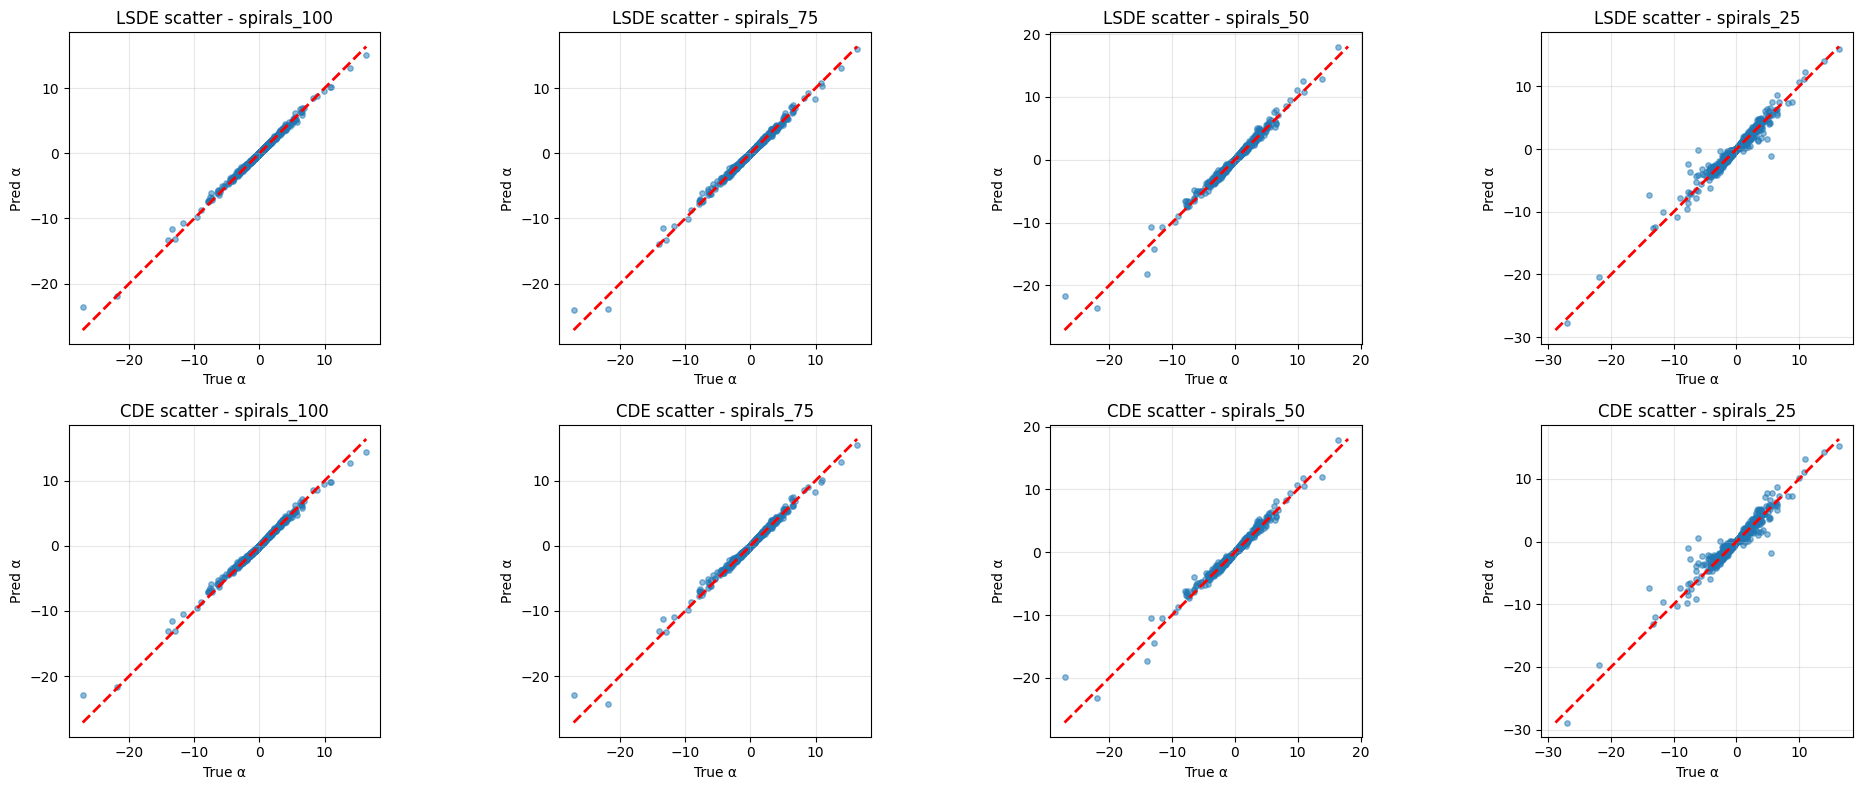

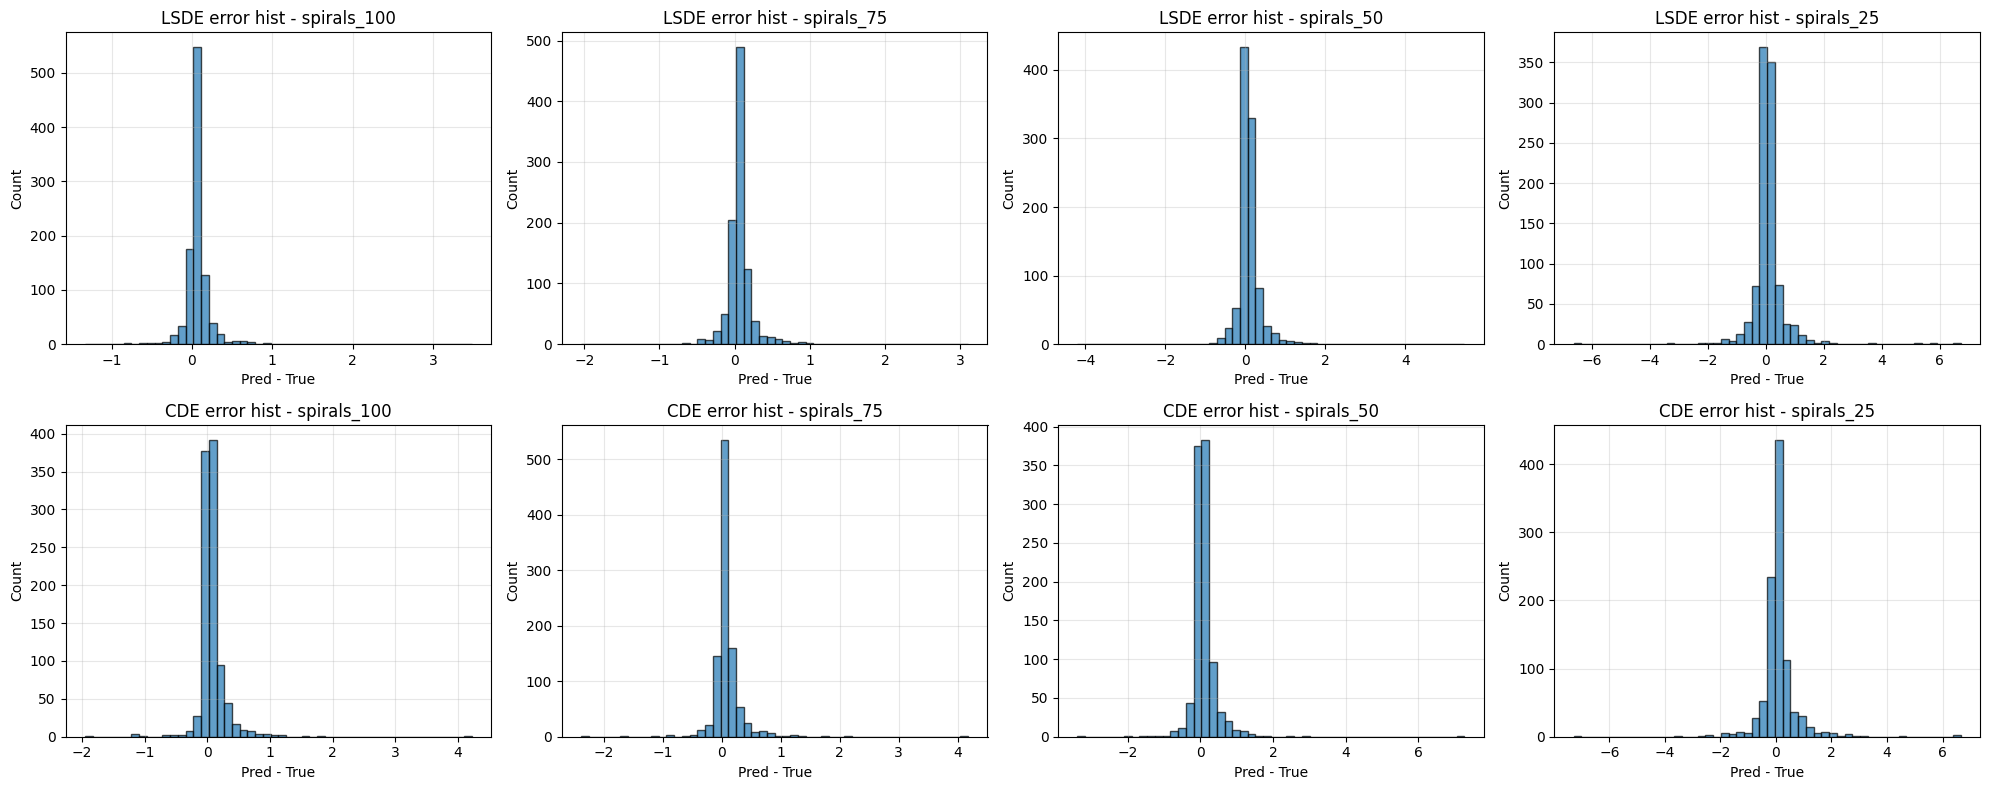

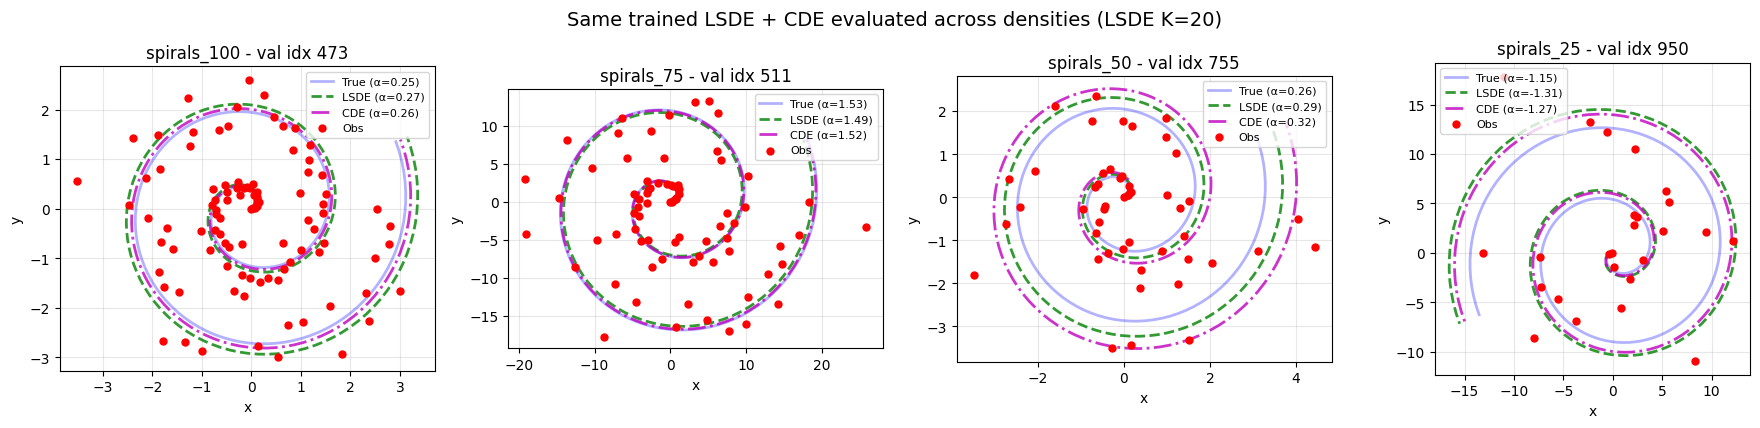

In [27]:
# Evaluate TWO trained models (LSDE + CDE) on ALL 4 spiral validation sets
# - Monte Carlo average LSDE predictions over K stochastic passes
# - Assumes these exist in your notebook namespace:
#   - model_lsde (NormalizedRegressor wrapping a trained LSDE)
#   - model_cde  (NormalizedRegressor wrapping a trained CDE)
#   - datasets   (loaded spirals datasets)
#
# Paste & run directly.

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

# ---- config ----
K = 20  # number of stochastic forward passes for LSDE evaluation (change to 5/10 for speed)
densities = ["100", "75", "50", "25"]

assert "model_lsde" in globals(), "Expected a trained `model_lsde` in globals()."
assert "model_cde" in globals(), "Expected a trained `model_cde` in globals()."
assert "datasets" in globals(), "Expected `datasets` in globals()."

def generate_true_spiral(alpha: float, t_max: float = 13.0, n_points: int = 200):
    ts = np.linspace(0, t_max, n_points)
    theta = ts
    r = alpha * theta
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.stack([x, y], axis=-1)

# reproducible: one trajectory index per density
rng = np.random.default_rng(1)
sample_idx_by_density = {d: int(rng.integers(0, len(datasets[d]["data_val"]))) for d in densities}

# ---- prediction helpers ----
def predict_batch_cde(model, data_batch):
    """Deterministic CDE model prediction for a batch.
    data_batch: (B,T,3). Returns jnp array shape (B,)"""
    preds = jax.vmap(lambda data: model(data))(data_batch)
    # ensure shape (B,)
    return jnp.squeeze(preds)

def predict_batch_lsde_k(model, data_batch, *, key, K: int):
    """
    Monte Carlo evaluation for LSDE:
    - Run K independent stochastic forwards, average predictions.
    - model: NormalizedRegressor wrapping LSDE
    - data_batch: (B,T,3)
    - key: base PRNGKey
    Returns jnp array shape (B,)
    """
    b = data_batch.shape[0]
    # split K top-level keys
    keys_k = jr.split(key, K)  # (K,)

    # one pass: uses a key for this pass and draws b subkeys (one per sample)
    def one_pass(kpass):
        keys_b = jr.split(kpass, b)  # (B,)
        # vmapped run over samples
        preds_b = jax.vmap(lambda data, kk: model(data, key=kk))(data_batch, keys_b)  # (B,) or (B,1)
        return jnp.squeeze(preds_b)

    # run K passes and average
    preds_kb = jax.vmap(one_pass)(keys_k)  # (K, B)
    mean_preds_b = jnp.mean(preds_kb, axis=0)  # (B,)
    return mean_preds_b

# ---------- 1) Per-density metrics + scatter plots ----------
fig_scatter, axes_scatter = plt.subplots(2, 4, figsize=(20, 8))
all_metrics = {"lsde": {}, "cde": {}}

eval_key = jr.PRNGKey(0)

for j, density in enumerate(densities):
    data_val = datasets[density]["data_val"]      # (B,T,3)
    alpha_val = datasets[density]["alpha_val"]    # (B,1) or (B,)

    data_val_jax = jnp.array(data_val, dtype=jnp.float32)
    alpha_val_np = np.array(alpha_val).reshape(-1)

    # LSDE predictions (stochastic averaged over K passes)
    eval_key, k_lsde = jr.split(eval_key, 2)
    alpha_pred_lsde = np.array(predict_batch_lsde_k(model_lsde, data_val_jax, key=k_lsde, K=K)).reshape(-1)

    # CDE predictions (deterministic)
    alpha_pred_cde = np.array(predict_batch_cde(model_cde, data_val_jax)).reshape(-1)

    # metrics
    err_lsde = alpha_pred_lsde - alpha_val_np
    err_cde = alpha_pred_cde - alpha_val_np

    mse_lsde = float(np.mean(err_lsde ** 2))
    mae_lsde = float(np.mean(np.abs(err_lsde)))
    std_lsde = float(np.std(err_lsde))

    mse_cde = float(np.mean(err_cde ** 2))
    mae_cde = float(np.mean(np.abs(err_cde)))
    std_cde = float(np.std(err_cde))

    all_metrics["lsde"][density] = {"mse": mse_lsde, "mae": mae_lsde, "std": std_lsde}
    all_metrics["cde"][density] = {"mse": mse_cde, "mae": mae_cde, "std": std_cde}

    print(f"\n📊 Validation performance on spirals_{density} (same trained models, LSDE averaged K={K})")
    print(f"   LSDE: MSE {mse_lsde:.6f} | MAE {mae_lsde:.6f} | Std {std_lsde:.6f}")
    print(f"   CDE : MSE {mse_cde:.6f} | MAE {mae_cde:.6f} | Std {std_cde:.6f}")

    lo = min(alpha_val_np.min(), alpha_pred_lsde.min(), alpha_pred_cde.min())
    hi = max(alpha_val_np.max(), alpha_pred_lsde.max(), alpha_pred_cde.max())

    ax0 = axes_scatter[0, j]
    ax0.scatter(alpha_val_np, alpha_pred_lsde, alpha=0.5, s=15)
    ax0.plot([lo, hi], [lo, hi], "r--", linewidth=2)
    ax0.set_title(f"LSDE scatter - spirals_{density}")
    ax0.set_xlabel("True α")
    ax0.set_ylabel("Pred α")
    ax0.grid(True, alpha=0.3)
    ax0.set_aspect("equal", adjustable="box")

    ax1 = axes_scatter[1, j]
    ax1.scatter(alpha_val_np, alpha_pred_cde, alpha=0.5, s=15)
    ax1.plot([lo, hi], [lo, hi], "r--", linewidth=2)
    ax1.set_title(f"CDE scatter - spirals_{density}")
    ax1.set_xlabel("True α")
    ax1.set_ylabel("Pred α")
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

# ---------- 2) Error histograms ----------
fig_hist, axes_hist = plt.subplots(2, 4, figsize=(20, 8))

for j, density in enumerate(densities):
    data_val = datasets[density]["data_val"]
    alpha_val = datasets[density]["alpha_val"]

    data_val_jax = jnp.array(data_val, dtype=jnp.float32)
    alpha_val_np = np.array(alpha_val).reshape(-1)

    eval_key, k_lsde = jr.split(eval_key, 2)
    alpha_pred_lsde = np.array(predict_batch_lsde_k(model_lsde, data_val_jax, key=k_lsde, K=K)).reshape(-1)
    alpha_pred_cde = np.array(predict_batch_cde(model_cde, data_val_jax)).reshape(-1)

    err_lsde = alpha_pred_lsde - alpha_val_np
    err_cde = alpha_pred_cde - alpha_val_np

    ax0 = axes_hist[0, j]
    ax0.hist(err_lsde, bins=50, edgecolor="black", alpha=0.7)
    ax0.set_title(f"LSDE error hist - spirals_{density}")
    ax0.set_xlabel("Pred - True")
    ax0.set_ylabel("Count")
    ax0.grid(True, alpha=0.3)

    ax1 = axes_hist[1, j]
    ax1.hist(err_cde, bins=50, edgecolor="black", alpha=0.7)
    ax1.set_title(f"CDE error hist - spirals_{density}")
    ax1.set_xlabel("Pred - True")
    ax1.set_ylabel("Count")
    ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---------- 3) One trajectory visualization per density (overlay LSDE + CDE) ----------
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
eval_key = jr.PRNGKey(123)

for ax, density in zip(axes, densities):
    data_val = datasets[density]["data_val"]
    alpha_val = datasets[density]["alpha_val"]

    sample_idx = sample_idx_by_density[density]
    traj = data_val[sample_idx]  # (T,3)
    traj_jax = jnp.array(traj, dtype=jnp.float32)
    alpha_true = float(np.array(alpha_val[sample_idx]).reshape(-1)[0])

    # LSDE single prediction averaged over K passes
    eval_key, k0 = jr.split(eval_key, 2)
    keys_k = jr.split(k0, K)  # (K,)
    preds_k = jax.vmap(lambda kk: model_lsde(traj_jax, key=kk))(keys_k)  # (K, 1) or (K,)
    alpha_pred_lsde = float(jnp.mean(jnp.squeeze(preds_k)))

    # CDE single prediction
    alpha_pred_cde = float(np.array(model_cde(traj_jax)).reshape(-1)[0])

    # observed points (mask NaNs)
    mask = ~np.isnan(traj[:, 1])
    observed_x = traj[mask, 1]
    observed_y = traj[mask, 2]

    true_spiral = generate_true_spiral(alpha_true, t_max=13.0, n_points=200)
    pred_spiral_lsde = generate_true_spiral(alpha_pred_lsde, t_max=13.0, n_points=200)
    pred_spiral_cde = generate_true_spiral(alpha_pred_cde, t_max=13.0, n_points=200)

    ax.plot(true_spiral[:, 0], true_spiral[:, 1],
            "b-", alpha=0.3, linewidth=2, label=f"True (α={alpha_true:.2f})")
    ax.plot(pred_spiral_lsde[:, 0], pred_spiral_lsde[:, 1],
            "g--", alpha=0.8, linewidth=2, label=f"LSDE (α={alpha_pred_lsde:.2f})")
    ax.plot(pred_spiral_cde[:, 0], pred_spiral_cde[:, 1],
            "m-.", alpha=0.8, linewidth=2, label=f"CDE (α={alpha_pred_cde:.2f})")

    ax.scatter(observed_x, observed_y, c="red", s=25, zorder=5, label="Obs")

    ax.set_title(f"spirals_{density} - val idx {sample_idx}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle(f"Same trained LSDE + CDE evaluated across densities (LSDE K={K})", fontsize=14, y=1.05)
plt.show()

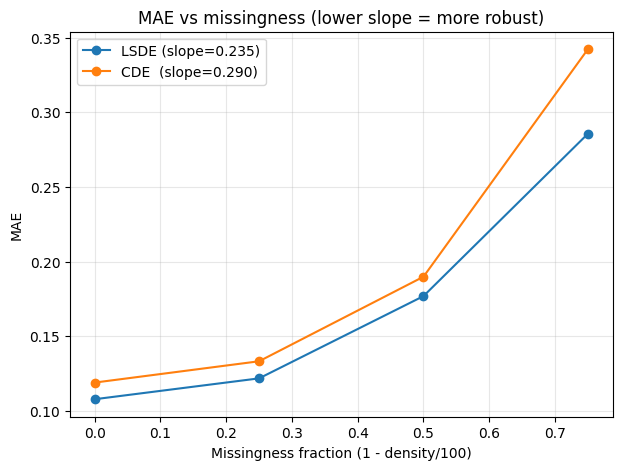

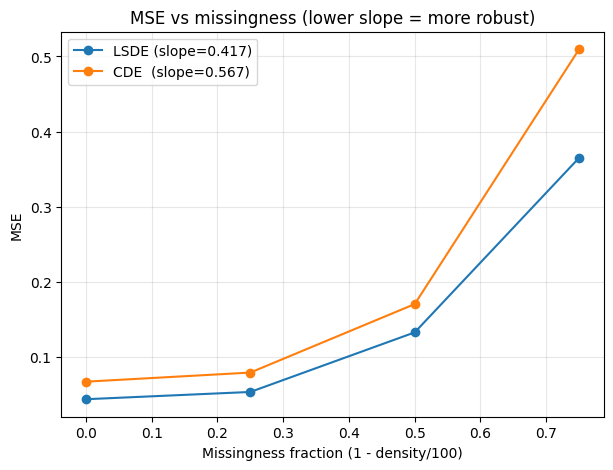

Slope summary (smaller is better / degrades more slowly):
  MAE slope: LSDE 0.235309 | CDE 0.290492
  MSE slope: LSDE 0.417296 | CDE 0.567481


In [26]:
# Add MAE/MSE vs missingness plots (LSDE vs CDE) using the `all_metrics` dict
# Assumes you already ran the evaluation cell and have:
# - all_metrics["lsde"][density]["mse"/"mae"]
# - all_metrics["cde"][density]["mse"/"mae"]

import numpy as np
import matplotlib.pyplot as plt

assert "all_metrics" in globals(), "Expected `all_metrics` in globals(). Run the eval cell first."

densities = ["100", "75", "50", "25"]

# missingness fraction: 0 at 100, 0.25 at 75, 0.5 at 50, 0.75 at 25
missingness = np.array([1.0 - (int(d) / 100.0) for d in densities], dtype=float)

lsde_mae = np.array([all_metrics["lsde"][d]["mae"] for d in densities], dtype=float)
cde_mae  = np.array([all_metrics["cde"][d]["mae"]  for d in densities], dtype=float)

lsde_mse = np.array([all_metrics["lsde"][d]["mse"] for d in densities], dtype=float)
cde_mse  = np.array([all_metrics["cde"][d]["mse"]  for d in densities], dtype=float)

# simple slope estimates (line fit) to quantify "degrades slower"
mae_slope_lsde, mae_intercept_lsde = np.polyfit(missingness, lsde_mae, 1)
mae_slope_cde,  mae_intercept_cde  = np.polyfit(missingness, cde_mae, 1)

mse_slope_lsde, mse_intercept_lsde = np.polyfit(missingness, lsde_mse, 1)
mse_slope_cde,  mse_intercept_cde  = np.polyfit(missingness, cde_mse, 1)

# ---- MAE vs missingness ----
plt.figure(figsize=(7, 5))
plt.plot(missingness, lsde_mae, marker="o", label=f"LSDE (slope={mae_slope_lsde:.3f})")
plt.plot(missingness, cde_mae,  marker="o", label=f"CDE  (slope={mae_slope_cde:.3f})")
plt.xlabel("Missingness fraction (1 - density/100)")
plt.ylabel("MAE")
plt.title("MAE vs missingness (lower slope = more robust)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ---- MSE vs missingness ----
plt.figure(figsize=(7, 5))
plt.plot(missingness, lsde_mse, marker="o", label=f"LSDE (slope={mse_slope_lsde:.3f})")
plt.plot(missingness, cde_mse,  marker="o", label=f"CDE  (slope={mse_slope_cde:.3f})")
plt.xlabel("Missingness fraction (1 - density/100)")
plt.ylabel("MSE")
plt.title("MSE vs missingness (lower slope = more robust)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Slope summary (smaller is better / degrades more slowly):")
print(f"  MAE slope: LSDE {mae_slope_lsde:.6f} | CDE {mae_slope_cde:.6f}")
print(f"  MSE slope: LSDE {mse_slope_lsde:.6f} | CDE {mse_slope_cde:.6f}")

## Conclusion

Across all evaluation settings, the Neural LSDE exhibits consistently lower error and a slower increase in both MAE and MSE as observation density decreases, compared to the deterministic Neural CDE. When analyzed as a function of missingness, the LSDE shows smaller linear slopes and lower exponential growth rates, indicating reduced sensitivity to changes in the observation process.

While this experiment is limited to a single synthetic task and a specific form of distribution shift, the observed trends are aligned with the original motivation behind Neural LSDEs. In particular, the results support the claim made in *Stable Neural Stochastic Differential Equations in Analyzing Irregular Time Series Data* that introducing stochasticity into latent dynamics can improve robustness under distribution shift.

These findings suggest that latent stochasticity may act as an effective regularizer in settings with irregular or missing observations. Further experiments across tasks, datasets, and sources of distribution shift would be needed to assess the generality of this effect.